# TDSC-ABUS 2023 — dataset visualization

A tour of the data this project classifies: what is in it, how balanced it is, what the tumors look
like in 2D and 3D, and which quantitative features separate malignant from benign lesions.

1. [Loading the dataset](#1-loading-the-dataset)
2. [Class balance](#2-class-balance)
3. [Sample tumors](#3-sample-tumors)
4. [Tumor shape in 3D](#4-tumor-shape-in-3d)
5. [Statistics for classification](#5-statistics-for-classification)

Everything is measured in millimetres, and every feature comes from `abus_classification.features`.
The features of Tan et al. (2012, 2013) are analysed separately in `tao2013.ipynb`.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import trimesh
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from sklearn.metrics import roc_auc_score

sys.path.append("..")

from tdsc_abus2023_pytorch import TDSC, TDSCTumors, DataSplits

from abus_classification.features import radiology
from abus_classification.utils.mesh import get_mesh_from_3d_mask, lesion_mesh
from abus_classification.utils.spacing import TDSC_DEPTH_AXIS, TDSC_SPACING, crop_around_mask

print(f"numpy {np.__version__} · pandas {pd.__version__} · trimesh {trimesh.__version__}")

numpy 2.5.3 · pandas 3.0.5 · trimesh 5.1.0


### Plot styling

One palette for the whole notebook. Malignant and benign are *identities*, not magnitudes, so they
get two categorical hues; everything else (grid, axes, labels) stays recessive ink so the data
carries the color.

In [2]:
SURFACE   = "#fcfcfb"   # chart surface
INK       = "#0b0b0b"   # primary text
INK_2     = "#52514e"   # secondary text
MUTED     = "#898781"   # axis labels / ticks
GRID      = "#e1e0d9"   # hairline gridlines
AXIS      = "#c3c2b7"   # baseline

MALIGNANT = "#eb6834"   # categorical slot 2 (orange)
BENIGN    = "#2a78d6"   # categorical slot 1 (blue)
ACCENT    = "#4a3aa7"   # single-series charts that are not about class

CLASS_COLOR = {0: MALIGNANT, 1: BENIGN}
CLASS_NAME  = {0: "Malignant", 1: "Benign"}

# Diverging pair for correlations: cool <-> warm with a neutral midpoint.
DIVERGING = mpl.colors.LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.labelsize": 9.5, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "legend.fontsize": 9, "figure.dpi": 110,
})


def fig_title(fig, title, subtitle=None, x=0.008):
    """Figure title + subtitle, spaced in inches so they never collide; returns the tight_layout rect top."""
    h = fig.get_figheight()
    fig.suptitle(title, x=x, y=1 - 0.26 / h, ha="left", va="top", fontsize=13, fontweight="bold", color=INK)
    if subtitle:
        fig.text(x, 1 - 0.58 / h, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    return 1 - (0.92 if subtitle else 0.62) / h


def value_grid(ax, axis="y"):
    """Recessive hairline grid on the value axis only, behind the marks."""
    ax.grid(True, axis=axis, color=GRID, linewidth=0.8, linestyle="-")
    ax.set_axisbelow(True)


def bare(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

## 1. Loading the dataset

`TDSC` yields whole ABUS volumes; `TDSCTumors` yields the same cases cropped to the annotated tumor
bounding box.

> **Note on `download=True`:** `tdsc-abus2023-pytorch` currently calls `download_dataset()`
> unconditionally, so passing it on every run re-downloads ~15 GB. The helper below only asks for a
> download when the split directory is actually missing.

In [3]:
DATA_ROOT = Path("../data/tdsc")
SPLITS = [DataSplits.TRAIN, DataSplits.VALIDATION, DataSplits.TEST]


def load_split(split, cls=TDSCTumors):
    """Load one split, downloading only if it is not already on disk."""
    missing = not (DATA_ROOT / str(split)).exists()
    if missing:
        print(f"{split} not found — downloading (this is several GB)...")
    return cls(path=str(DATA_ROOT), split=split, download=missing)


tumors = {s: load_split(s, TDSCTumors) for s in SPLITS}
volumes = {s: load_split(s, TDSC) for s in SPLITS}

for s in SPLITS:
    print(f"{str(s):11s} {len(tumors[s]):3d} cases")
print(f"{'TOTAL':11s} {sum(len(d) for d in tumors.values()):3d} cases")

Train       100 cases
Validation   30 cases
Test         70 cases
TOTAL       200 cases


### Voxels are not cubes

The NRRD files do not record voxel size. The TDSC-ABUS challenge paper does: each acquired ultrasound
image has pixels of **0.200 mm** along the transducer and **0.073 mm** in depth, and the images are
stacked **0.476 mm** apart as the transducer sweeps across the breast. In the arrays that makes

| axis | runs along | voxel size |
|---|---|---|
| 0 | the transducer | 0.200 mm |
| 1 | the beam, into the breast (depth) | 0.073 mm |
| 2 | the sweep | 0.476 mm |

so a voxel is 6.5x longer on axis 2 than on axis 1. That also names the planes through a volume:

- slices **across axis 2** are the acquired **transversal** images, the view a handheld scan shows;
- slices **across axis 1** are **coronal** planes, parallel to the skin;
- slices **across axis 0** are **sagittal** reconstructions.

`ViewTransposeConfig` in `tdsc-abus2023-pytorch` labels axis 0 "axial" and axis 2 "sagittal", which
does not match this; the names here follow the acquisition geometry.

In [4]:
PLANE_NAME = {0: "Sagittal", 1: "Coronal", 2: "Transversal"}
RUNS_ALONG = {0: "transducer", 1: "depth", 2: "sweep"}

full_vol, full_mask, label, bbox = volumes[DataSplits.TRAIN][0]
crop_vol, crop_mask, _ = tumors[DataSplits.TRAIN][0]
voxel_mm3 = float(np.prod(TDSC_SPACING))


def mm(shape):
    return " x ".join(f"{n * s:.1f}" for n, s in zip(shape, TDSC_SPACING))


overview = pd.DataFrame([
    ("Full volume", " x ".join(map(str, full_vol.shape)), mm(full_vol.shape) + " mm", f"{full_vol.size / 1e6:.0f} M voxels"),
    ("Cropped volume", " x ".join(map(str, crop_vol.shape)), mm(crop_vol.shape) + " mm", f"{crop_vol.size / 1e6:.2f} M voxels"),
    ("Lesion", "", "", f"{int(full_mask.sum()) * voxel_mm3:,.0f} mm³"),
], columns=["array", "voxels", "physical size", "size"])

print(f"case 0 — label {label} ({CLASS_NAME[label]})")
print(f"the lesion occupies {100 * full_mask.sum() / full_mask.size:.3f}% of the scanned volume")
overview

case 0 — label 0 (Malignant)
the lesion occupies 0.139% of the scanned volume


,array,voxels,physical size,size
0,Full volume,865 x 608 x 330,173.0 x 44.4 x 157.0 mm,174 M voxels
1,Cropped volume,114 x 256 x 35,22.8 x 18.7 x 16.6 mm,1.02 M voxels
2,Lesion,,,"1,676 mm³"


## 2. Class balance

The label is the thing being predicted, so its distribution sets the floor for any accuracy claim: a
classifier that always answers "malignant" already scores whatever the malignant share is. Counts come
from each split's `labels.csv`, so this cell reads no image data.

In [5]:
labels = pd.concat(
    [d.metadata[["label"]].assign(split=str(s)) for s, d in tumors.items()]
).reset_index()
labels["class"] = labels["label"].map({"M": "Malignant", "B": "Benign"})

balance = (
    labels.pivot_table(index="split", columns="class", values="case_id", aggfunc="count")
    .reindex([str(s) for s in SPLITS])
    .fillna(0).astype(int)
)
balance["Total"] = balance.sum(axis=1)
balance["Malignant %"] = (100 * balance["Malignant"] / balance["Total"]).round(1)
balance.loc["All"] = balance.sum()
balance.loc["All", "Malignant %"] = round(100 * balance.loc["All", "Malignant"] / balance.loc["All", "Total"], 1)

counts = ["Malignant", "Benign", "Total"]
balance[counts] = balance[counts].astype(int)   # summing in a float column promoted these
balance

class,Benign,Malignant,Total,Malignant %
split,,,,
Train,42,58,100,58.0
Validation,13,17,30,56.7
Test,30,40,70,57.1
All,85,115,200,57.5


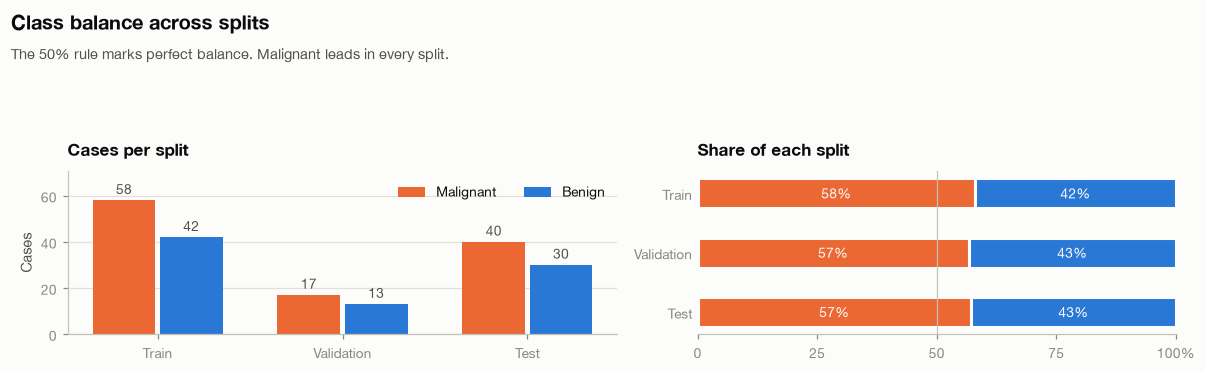

In [6]:
splits = [str(s) for s in SPLITS]
mal = balance.loc[splits, "Malignant"].to_numpy().astype(int)
ben = balance.loc[splits, "Benign"].to_numpy().astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.15, 1]})

x = np.arange(len(splits))
w = 0.34
ax1.bar(x - w/2 - 0.012, mal, w, color=MALIGNANT, label="Malignant")
ax1.bar(x + w/2 + 0.012, ben, w, color=BENIGN, label="Benign")
for xi, (m, b) in enumerate(zip(mal, ben)):
    ax1.text(xi - w/2 - 0.012, m + 1.5, str(m), ha="center", va="bottom", fontsize=9, color=INK_2)
    ax1.text(xi + w/2 + 0.012, b + 1.5, str(b), ha="center", va="bottom", fontsize=9, color=INK_2)
ax1.set_xticks(x, splits)
ax1.set_ylabel("Cases")
ax1.set_ylim(0, max(mal.max(), ben.max()) * 1.22)
ax1.set_title("Cases per split")
value_grid(ax1)
ax1.legend(loc="upper right", ncols=2)

total = mal + ben
mal_pct, ben_pct = 100 * mal / total, 100 * ben / total
y = np.arange(len(splits))[::-1]
ax2.barh(y, mal_pct, 0.5, color=MALIGNANT, edgecolor=SURFACE, linewidth=2)
ax2.barh(y, ben_pct, 0.5, left=mal_pct, color=BENIGN, edgecolor=SURFACE, linewidth=2)
for yi, (mp, bp) in enumerate(zip(mal_pct[::-1], ben_pct[::-1])):
    ax2.text(mp / 2, y[::-1][yi], f"{mp:.0f}%", ha="center", va="center", color=SURFACE, fontsize=9)
    ax2.text(mp + bp / 2, y[::-1][yi], f"{bp:.0f}%", ha="center", va="center", color=SURFACE, fontsize=9)
ax2.axvline(50, color=AXIS, linewidth=0.8, zorder=3)
ax2.set_yticks(y, splits)
ax2.set_xlim(0, 100)
ax2.set_xticks([0, 25, 50, 75, 100], ["0", "25", "50", "75", "100%"])
ax2.set_title("Share of each split")
ax2.spines["left"].set_visible(False)
ax2.tick_params(axis="y", length=0)

top = fig_title(fig, "Class balance across splits",
                "The 50% rule marks perfect balance. Malignant leads in every split.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

## 3. Sample tumors

Counted in voxels, the average lesion's bounding box is about 5x shorter along the sweep than in
depth, as if lesions were thin slabs. That is the voxel shape, not the anatomy. In millimetres the
lesions are far more even:

In [7]:
bboxes = pd.concat([d.bbx_metadata for d in tumors.values()])
extent_voxels = bboxes[["len_z", "len_y", "len_x"]].to_numpy(float)   # array axes 0, 1, 2
extent_mm = extent_voxels * np.array(TDSC_SPACING)

pd.DataFrame({
    "axis": [0, 1, 2],
    "runs along": [RUNS_ALONG[a] for a in range(3)],
    "voxel size (mm)": TDSC_SPACING,
    "mean lesion extent (voxels)": extent_voxels.mean(axis=0).round(0).astype(int),
    "mean lesion extent (mm)": extent_mm.mean(axis=0).round(1),
}).set_index("axis")

,runs along,voxel size (mm),mean lesion extent (voxels),mean lesion extent (mm)
axis,,,,
0,transducer,0.200000,128,25.5
1,depth,0.073000,169,12.3
2,sweep,0.475674,32,15.4


Every image below is therefore drawn in millimetres. The gallery shows the **transversal** plane
through each tumor's centre of mass — the acquired ultrasound image, with the transducer at the top —
with the annotated mask outlined in the class color. All panels share one window and one scale.

In [8]:
def lesion_crop(vol, mask, margin_mm=25.0):
    """A full volume cut down to the lesion plus `margin_mm` of surrounding tissue."""
    box = crop_around_mask(mask, TDSC_SPACING, margin_mm)
    return vol[box], mask[box] > 0


def plane(vol, mask, axis, index=None):
    """
    A 2D plane through the lesion, positioned in millimetres.

    Depth runs down the image whenever the plane contains it. Returns the image,
    the mask, and an imshow extent centred on the lesion's centre of mass.
    """
    centre = np.argwhere(mask).mean(axis=0)
    index = int(round(centre[axis])) if index is None else int(index)
    image, outline = np.take(vol, index, axis=axis), np.take(mask, index, axis=axis)
    rows_axis, cols_axis = [a for a in range(3) if a != axis]
    if cols_axis == TDSC_DEPTH_AXIS:
        image, outline = image.T, outline.T
        rows_axis, cols_axis = cols_axis, rows_axis
    rs, cs = TDSC_SPACING[rows_axis], TDSC_SPACING[cols_axis]
    rc, cc = centre[rows_axis], centre[cols_axis]
    extent = [(-0.5 - cc) * cs, (image.shape[1] - 0.5 - cc) * cs,
              (image.shape[0] - 0.5 - rc) * rs, (-0.5 - rc) * rs]
    return image, outline, extent


def lesion_window(mask, axis, margin_mm=8.0):
    """Height and width in mm of the lesion's footprint on a plane, plus a margin."""
    _, outline, _ = plane(mask.astype(np.uint8), mask, axis)
    rows_axis, cols_axis = [a for a in range(3) if a != axis]
    if cols_axis == TDSC_DEPTH_AXIS:
        rows_axis, cols_axis = cols_axis, rows_axis
    points = np.argwhere(mask)
    return ((np.ptp(points[:, rows_axis]) + 1) * TDSC_SPACING[rows_axis] + margin_mm,
            (np.ptp(points[:, cols_axis]) + 1) * TDSC_SPACING[cols_axis] + margin_mm)


def show_plane(ax, vol, mask, axis, window_mm, color, title=None, subtitle=None, index=None, linewidth=1.6):
    image, outline, extent = plane(vol, mask, axis, index)
    ax.imshow(image, cmap="gray", vmin=0, vmax=255, extent=extent, interpolation="nearest")
    if outline.any():
        ax.contour(outline, levels=[0.5], colors=[color], linewidths=linewidth, extent=extent, origin="upper")
    height, width = window_mm
    ax.set_xlim(-width / 2, width / 2)
    ax.set_ylim(height / 2, -height / 2)
    ax.set_aspect("equal")
    bare(ax)
    if title:
        ax.set_title(title, fontsize=9.5, pad=4)
    if subtitle:
        ax.text(0.5, -0.03, subtitle, transform=ax.transAxes, ha="center", va="top", fontsize=8, color=MUTED)


def scale_bar(ax, window_mm, length_mm=10):
    height, width = window_mm
    x0, y0 = -width / 2 + 0.06 * width, height / 2 - 0.07 * height
    ax.plot([x0, x0 + length_mm], [y0, y0], color="white", linewidth=2.5, solid_capstyle="butt")
    ax.text(x0 + length_mm / 2, y0 - 0.03 * height, f"{length_mm} mm", color="white",
            ha="center", va="bottom", fontsize=8)

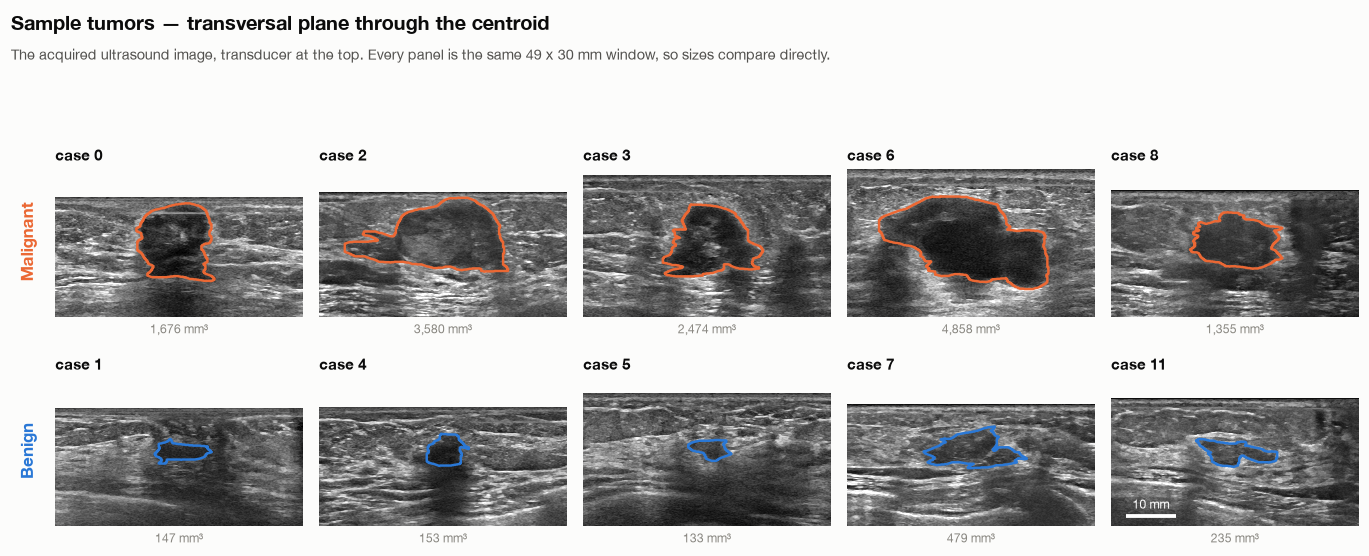

In [9]:
train_full = volumes[DataSplits.TRAIN]
train_labels = train_full.metadata["label"].to_numpy()
mal_idx = np.flatnonzero(train_labels == "M")[:5]
ben_idx = np.flatnonzero(train_labels == "B")[:5]
samples = [(int(i), 0) for i in mal_idx] + [(int(i), 1) for i in ben_idx]

crops = {}
for i, _ in samples:
    vol, mask, _, _ = train_full[i]
    crops[i] = lesion_crop(vol, mask)

window = tuple(np.max([lesion_window(m, axis=2) for _, m in crops.values()], axis=0))
window = (min(window[0], 40.0), window[1])

fig, axes = plt.subplots(2, 5, figsize=(12.5, 2 * (12.5 / 5) * window[0] / window[1] + 2.3))
for n, (i, cls) in enumerate(samples):
    vol, mask = crops[i]
    ax = axes[n // 5, n % 5]
    show_plane(ax, vol, mask, axis=2, window_mm=window, color=CLASS_COLOR[cls],
               title=f"case {train_full.metadata.index[i]}",
               subtitle=f"{radiology.lesion_volume(mask, TDSC_SPACING):,.0f} mm³")
for row, cls in enumerate((0, 1)):
    axes[row, 0].set_ylabel(CLASS_NAME[cls], fontsize=11, fontweight="bold", color=CLASS_COLOR[cls], labelpad=12)
scale_bar(axes[1, 4], window)

top = fig_title(fig, "Sample tumors — transversal plane through the centroid",
                f"The acquired ultrasound image, transducer at the top. Every panel is the same "
                f"{window[1]:.0f} x {window[0]:.0f} mm window, so sizes compare directly.")
fig.tight_layout(rect=[0, 0, 1, top], h_pad=4.0)
plt.show()

### One tumor in three planes

The same lesion in the transversal, sagittal and coronal planes through its centre, at one scale, and
a run of transversal slices across the sweep showing how the cross-section grows and shrinks.

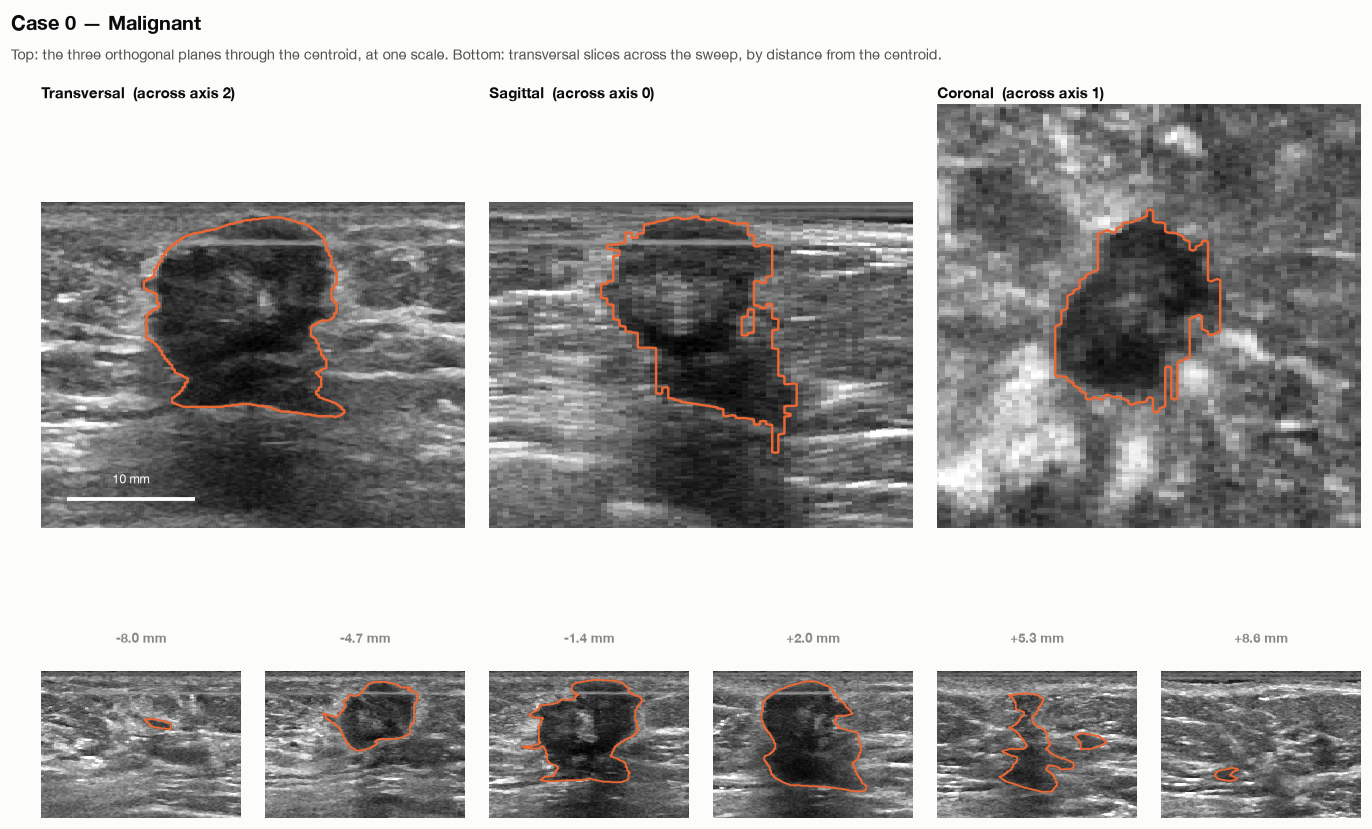

In [10]:
case_index = int(mal_idx[0])
vol, mask = crops[case_index]
color = MALIGNANT
points = np.argwhere(mask)
centre = points.mean(axis=0)

plane_axes = (2, 0, 1)
window3 = tuple(np.max([lesion_window(mask, axis=a, margin_mm=10.0) for a in plane_axes], axis=0))
strip_positions = np.linspace(points[:, 2].min(), points[:, 2].max(), 6).round().astype(int)
strip_window = lesion_window(mask, axis=2, margin_mm=6.0)

plane_h = (12.5 / 3) * window3[0] / window3[1]
strip_h = (12.5 / 6) * strip_window[0] / strip_window[1]
fig_h = plane_h + strip_h + 2.2
fig = plt.figure(figsize=(12.5, fig_h))
gs = fig.add_gridspec(2, 6, height_ratios=[plane_h, strip_h], hspace=0.3, wspace=0.12,
                      left=0.03, right=0.99, top=1 - 1.0 / fig_h, bottom=0.45 / fig_h)

for n, axis in enumerate(plane_axes):
    ax = fig.add_subplot(gs[0, n * 2:(n + 1) * 2])
    show_plane(ax, vol, mask, axis=axis, window_mm=window3, color=color,
               title=f"{PLANE_NAME[axis]}  (across axis {axis})")
    if n == 0:
        scale_bar(ax, window3)

for col, k in enumerate(strip_positions):
    ax = fig.add_subplot(gs[1, col])
    show_plane(ax, vol, mask, axis=2, window_mm=strip_window, color=color, index=k, linewidth=1.2)
    ax.set_title(f"{(k - centre[2]) * TDSC_SPACING[2]:+.1f} mm", fontsize=8.5, color=MUTED, pad=3, loc="center")

fig_title(fig, f"Case {train_full.metadata.index[case_index]} — {CLASS_NAME[0]}",
          "Top: the three orthogonal planes through the centroid, at one scale. "
          "Bottom: transversal slices across the sweep, by distance from the centroid.")
plt.show()

## 4. Tumor shape in 3D

`abus_classification.utils.mesh.lesion_mesh` runs marching cubes over the binary mask, in millimetres,
and returns a `trimesh.Trimesh`. It wraps `get_mesh_from_3d_mask` with the two settings these masks
need. Both show up as a *negative* mesh volume when they are wrong — trimesh cannot orient the faces of
an open surface, so `fix_normals()` leaves the winding inside-out.

**1. Pad the mask.** `TDSCTumors` crops exactly to the bounding box, so the lesion touches the crop faces
and marching cubes leaves the surface open. Two zero voxels of padding close it.

**2. Turn the preprocessing off.** `preprocess_binary_mask` applies a morphological closing that pinches
thin structures into non-manifold geometry. On these masks it breaks 8 of the 200 cases — all of them
large, high-genus malignant lesions — and no amount of extra padding recovers them. The masks are
hand-drawn annotations that are already clean, so there is nothing for the closing to fix:

| `get_mesh_from_3d_mask` on a mask padded by 2 | not watertight | negative volume |
|---|---|---|
| `preprocess=True` (the default) | 8 / 200 | 8 / 200 |
| `preprocess=False` | **0 / 200** | **0 / 200** |

With `preprocess=False` the mesh volume lands within 0.2% of the mask volume across all 200 cases
(ratio 0.998 ± 0.002), which is the accuracy you would expect from marching cubes.

In [11]:
# Measured, not asserted: case 2 is one of the eight the closing breaks.
_, probe_mask, _ = tumors[DataSplits.TRAIN][2]
rows = []
for name, pad, prep in [("raw crop", 0, True), ("padded by 2", 2, True), ("padded by 2", 2, False)]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        g = get_mesh_from_3d_mask(np.pad((probe_mask > 0).astype(np.uint8), pad), spacing=TDSC_SPACING, preprocess=prep)
    rows.append({"mask": name, "preprocess": prep, "watertight": g.is_watertight,
                 "mesh volume (mm³)": round(g.volume), "mask volume (mm³)": round((probe_mask > 0).sum() * voxel_mm3)})
pd.DataFrame(rows)

,mask,preprocess,watertight,mesh volume (mm³),mask volume (mm³)
0,raw crop,True,False,-3638,3578
1,padded by 2,True,False,-3686,3578
2,padded by 2,False,True,3575,3578


In [12]:
def render_mesh(ax, mesh, color, title, subtitle=None):
    v = mesh.vertices
    xyz = np.column_stack([v[:, 0], v[:, 2], -v[:, 1]])     # transducer, sweep, depth pointing down
    collection = Poly3DCollection(xyz[mesh.faces], alpha=0.85, facecolor=color, edgecolor="none")
    collection.set_zsort("average")
    ax.add_collection3d(collection)

    lo, hi = xyz.min(axis=0), xyz.max(axis=0)
    extent = hi - lo
    pad = extent.max() * 0.04
    ax.set_xlim(lo[0] - pad, hi[0] + pad)
    ax.set_ylim(lo[1] - pad, hi[1] + pad)
    ax.set_zlim(lo[2] - pad, hi[2] + pad)
    ax.set_box_aspect(extent / extent.max())             # true physical proportions
    ax.view_init(elev=20, azim=-58)

    for label, setter in (("transducer", ax.set_xlabel), ("sweep", ax.set_ylabel), ("depth", ax.set_zlabel)):
        setter(label, labelpad=-8, fontsize=8, color=MUTED)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.tick_params(length=0)
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis):
        pane.pane.set_facecolor(SURFACE)
        pane.pane.set_edgecolor(GRID)
        pane._axinfo["grid"]["color"] = GRID
        pane._axinfo["grid"]["linewidth"] = 0.6
    ax.set_title(title, fontsize=10.5, pad=-2, color=INK)
    if subtitle:
        ax.text2D(0.5, -0.02, subtitle, transform=ax.transAxes, ha="center", va="top", fontsize=8.5, color=MUTED)

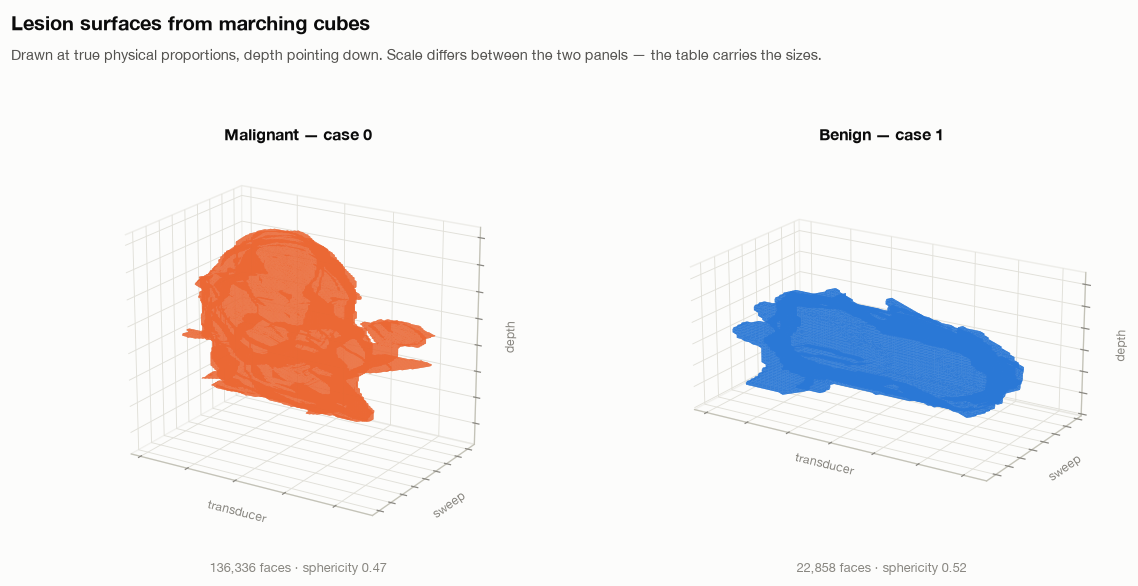

,class,extent transducer x depth x sweep (mm),mesh volume (mm³),surface area (mm²),sphericity,watertight
case,,,,,,
0,Malignant,22.8 x 18.7 x 16.6,1673,1466,0.465,True
1,Benign,12.6 x 5.6 x 7.1,143,254,0.523,True


In [13]:
train = tumors[DataSplits.TRAIN]
picks = [(int(mal_idx[0]), 0), (int(ben_idx[0]), 1)]

fig = plt.figure(figsize=(11, 5.4))
stats = []
for n, (i, cls) in enumerate(picks):
    _, m, _ = train[i]
    m = m > 0
    mesh = lesion_mesh(m, spacing=TDSC_SPACING)
    ax = fig.add_subplot(1, 2, n + 1, projection="3d")
    render_mesh(ax, mesh, CLASS_COLOR[cls], f"{CLASS_NAME[cls]} — case {train.metadata.index[i]}",
                f"{len(mesh.faces):,} faces · sphericity {radiology.sphericity(m, TDSC_SPACING):.2f}")
    extent = (np.ptp(np.argwhere(m), axis=0) + 1) * np.array(TDSC_SPACING)
    stats.append({
        "case": train.metadata.index[i],
        "class": CLASS_NAME[cls],
        "extent transducer x depth x sweep (mm)": " x ".join(f"{e:.1f}" for e in extent),
        "mesh volume (mm³)": round(mesh.volume),
        "surface area (mm²)": round(mesh.area),
        "sphericity": round(radiology.sphericity(m, TDSC_SPACING), 3),
        "watertight": mesh.is_watertight,
    })

top = fig_title(fig, "Lesion surfaces from marching cubes",
                "Drawn at true physical proportions, depth pointing down. Scale differs between the two "
                "panels — the table carries the sizes.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

pd.DataFrame(stats).set_index("case")

`mesh.show()` opens the same surface in trimesh's interactive viewer if you want to rotate it (it needs
a windowing backend, so it is left out of the executed notebook).

## 5. Statistics for classification

`radiology.extract_radiology_features` computes a general radiomic feature set for each lesion. It crops
the full volume with a few millimetres of surrounding tissue and resamples it to 0.6 mm cubic voxels
first, so shape features see true proportions and texture is measured on square pixels.

| Group | Features |
|---|---|
| Shape | volume (mm³), surface area (mm²), surface-to-volume, sphericity, compactness, height-to-width ratio, elongation, flatness, bounding-box fill |
| Margin | margin contrast (1.2 mm shells), boundary fractal dimension, radial distance deviation |
| Echo pattern | mean intensity, intensity variance, entropy, posterior acoustic contrast |
| Texture | GLCM contrast, dissimilarity, homogeneity, energy, correlation — widest coronal cross-section |

Features are computed once for all 200 lesions and cached.

In [14]:
CACHE = Path("../data/radiology_features.csv")

if CACHE.exists():
    features = pd.read_csv(CACHE)
    print(f"loaded {len(features)} cached rows from {CACHE}")
else:
    rows, t0 = [], time.time()
    for split, ds in volumes.items():
        for i in range(len(ds)):
            vol, mask, label, _ = ds[i]
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                values = radiology.extract_radiology_features(vol, mask)
            rows.append({"split": str(split), "case": int(ds.metadata.index[i]), "label": int(label),
                         "class": CLASS_NAME[int(label)], **values})
        print(f"  {split}: {len(ds)} lesions  ({time.time() - t0:.0f}s elapsed)")
    features = pd.DataFrame(rows)
    features.to_csv(CACHE, index=False)
    print(f"extracted {len(features)} lesions in {time.time() - t0:.0f}s -> {CACHE}")

FEATURE_COLS = list(radiology.RADIOLOGY_FEATURES)
missing = features[FEATURE_COLS].isna().sum()
print("missing values:", dict(missing[missing > 0]) or "none")
features.head()

loaded 200 cached rows from ../data/radiology_features.csv
missing values: none


,split,case,label,class,volume,surface_area,surface_to_volume,sphericity,compactness,height_to_width_ratio,...,radial_distance_deviation,mean_intensity,intensity_variance,entropy,posterior_acoustic,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation
0,Train,0,0,Malignant,1697.885084,1211.587209,0.713586,0.568070,5.455004,0.842088,...,0.221394,59.130688,713.252441,4.934655,-0.255045,717.549960,19.504001,0.061831,0.032599,0.713124
1,Train,1,1,Benign,146.111779,214.439889,1.467643,0.625608,4.084077,0.453103,...,0.333767,48.513805,171.597092,4.740382,-0.066319,173.716041,9.561509,0.124963,0.063914,0.680030
2,Train,2,0,Malignant,3542.139030,2257.260776,0.637259,0.497828,8.105161,0.532158,...,0.292566,76.239799,389.227600,4.641103,0.160970,560.695725,16.960891,0.069857,0.020974,0.799552
3,Train,3,0,Malignant,2447.156430,1402.492177,0.573111,0.626169,4.073104,0.680053,...,0.156295,54.957642,637.273499,4.542759,0.085349,358.668222,13.737441,0.084096,0.026669,0.878454
4,Train,4,1,Benign,144.455837,184.123992,1.274604,0.723098,2.644896,0.572047,...,0.238902,51.343784,531.256104,4.516683,-0.475463,550.723438,16.180845,0.066131,0.066647,0.793026


### Summary by class

Mean ± standard deviation per class, with two separability measures: **Cohen's d** (standardised
difference of means, malignant minus benign) and the **AUC** of the feature used alone as a classifier,
with malignant as the positive class. AUC 0.5 means no signal; above 0.5 the feature is higher in
malignant lesions, below 0.5 higher in benign ones.

In [15]:
malignant = (features["label"] == 0).to_numpy()
mal_rows, ben_rows = features[malignant], features[~malignant]

summary = []
for c in FEATURE_COLS:
    x = features[c].to_numpy(float)
    ok = np.isfinite(x)
    a, b = x[malignant & ok], x[~malignant & ok]
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    auc = roc_auc_score(malignant[ok], x[ok])
    summary.append({
        "feature": c,
        "malignant": f"{a.mean():.3g} ± {a.std(ddof=1):.2g}",
        "benign": f"{b.mean():.3g} ± {b.std(ddof=1):.2g}",
        "cohens_d": (a.mean() - b.mean()) / pooled if pooled else 0.0,
        "auc": auc,
        "separability": abs(auc - 0.5),
    })

summary = pd.DataFrame(summary).sort_values("separability", ascending=False).reset_index(drop=True)
summary.style.format({"cohens_d": "{:+.2f}", "auc": "{:.3f}", "separability": "{:.3f}"}).background_gradient(
    subset=["separability"], cmap="Blues")

,feature,malignant,benign,cohens_d,auc,separability
0,boundary_fractal_dimension,1.86 ± 0.12,1.74 ± 0.15,+0.91,0.749,0.249
1,surface_area,1.77e+03 ± 2e+03,722 ± 7.4e+02,+0.65,0.742,0.242
2,compactness,8.16 ± 4.1,5.43 ± 3.6,+0.70,0.740,0.240
3,sphericity,0.524 ± 0.086,0.601 ± 0.089,-0.89,0.260,0.240
4,volume,2.94e+03 ± 5.4e+03,994 ± 1.5e+03,+0.47,0.731,0.231
5,glcm_energy,0.0348 ± 0.015,0.0463 ± 0.019,-0.68,0.292,0.208
6,surface_to_volume,0.909 ± 0.32,1.16 ± 0.43,-0.68,0.323,0.177
7,margin_contrast,-32.3 ± 7.7,-37.6 ± 8.8,+0.64,0.670,0.170
8,bounding_box_fill,0.254 ± 0.061,0.288 ± 0.076,-0.51,0.338,0.162
9,flatness,0.496 ± 0.12,0.431 ± 0.12,+0.55,0.649,0.149


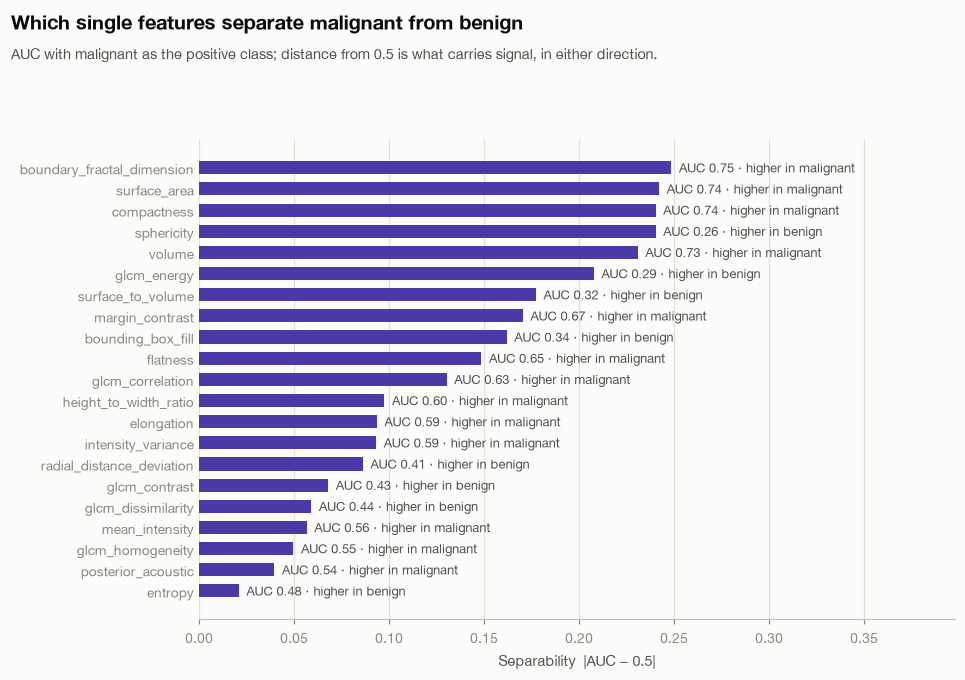

In [16]:
rank = summary.sort_values("separability")
fig, ax = plt.subplots(figsize=(8.8, 6.4))

yy = np.arange(len(rank))
ax.barh(yy, rank["separability"], height=0.62, color=ACCENT)
for yi, (v, auc) in enumerate(zip(rank["separability"], rank["auc"])):
    direction = "higher in malignant" if auc >= 0.5 else "higher in benign"
    ax.text(v + 0.004, yi, f"AUC {auc:.2f} · {direction}", va="center", ha="left", fontsize=8.5, color=INK_2)

ax.set_yticks(yy, rank["feature"])
ax.set_xlabel("Separability  |AUC − 0.5|")
ax.set_xlim(0, rank["separability"].max() * 1.6)
value_grid(ax, axis="x")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

top = fig_title(fig, "Which single features separate malignant from benign",
                "AUC with malignant as the positive class; distance from 0.5 is what carries signal, "
                "in either direction.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

### Distributions of the strongest features

Box plots for the six most separable features, malignant against benign.

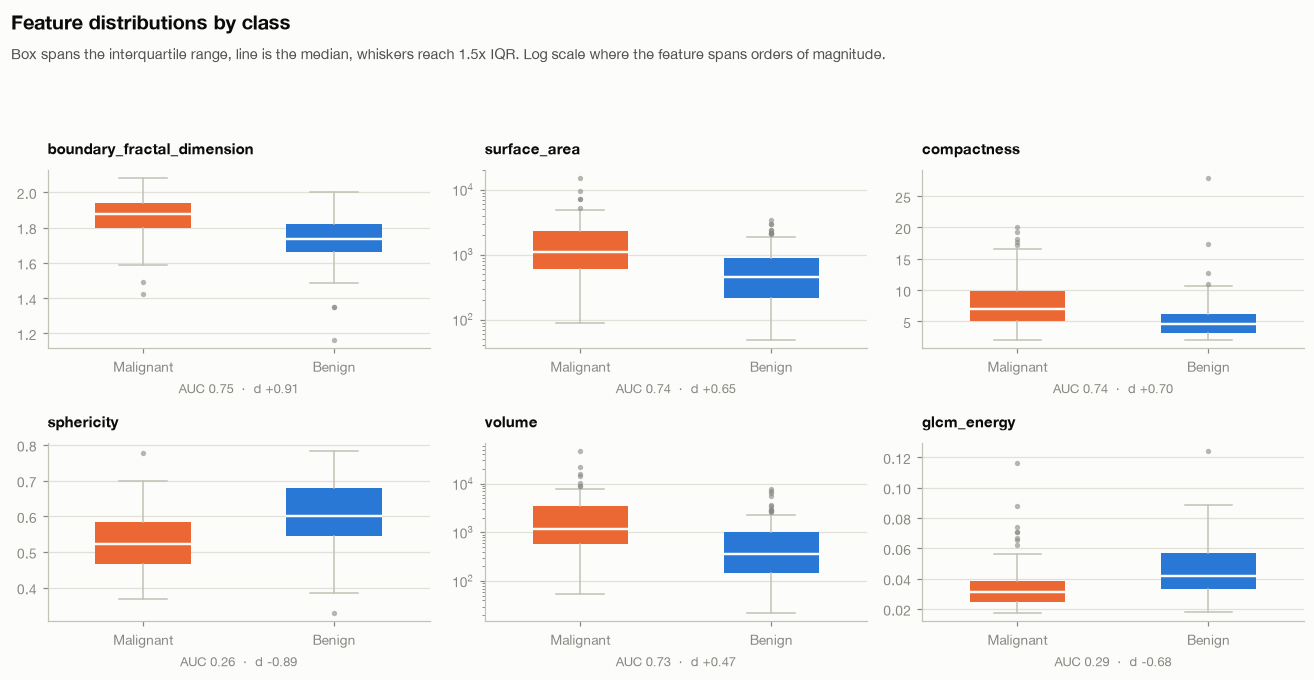

In [17]:
top6 = summary.head(6)["feature"].tolist()
LOG_SCALE = {"volume", "surface_area", "intensity_variance"}

fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
for ax, feat in zip(axes.ravel(), top6):
    data = [mal_rows[feat].dropna().to_numpy(), ben_rows[feat].dropna().to_numpy()]
    bp = ax.boxplot(data, positions=[0, 1], widths=0.5, patch_artist=True,
                    medianprops=dict(color=SURFACE, linewidth=1.6),
                    whiskerprops=dict(color=AXIS, linewidth=1),
                    capprops=dict(color=AXIS, linewidth=1),
                    flierprops=dict(marker="o", markersize=3.5, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.6))
    for patch, cls in zip(bp["boxes"], (0, 1)):
        patch.set_facecolor(CLASS_COLOR[cls])
        patch.set_edgecolor("none")
    if feat in LOG_SCALE:
        ax.set_yscale("log")
    ax.set_xticks([0, 1], [CLASS_NAME[0], CLASS_NAME[1]])
    row = summary[summary["feature"] == feat].iloc[0]
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel(f"AUC {row['auc']:.2f}  ·  d {row['cohens_d']:+.2f}", fontsize=8.5, color=MUTED)
    value_grid(ax)

top = fig_title(fig, "Feature distributions by class",
                "Box spans the interquartile range, line is the median, whiskers reach 1.5x IQR. "
                "Log scale where the feature spans orders of magnitude.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

### Feature correlation

Correlation is a *polarity* scale, so it takes a diverging map: one hue per sign, neutral gray at zero.
Tight blocks of near-1 correlation mean those features are redundant.

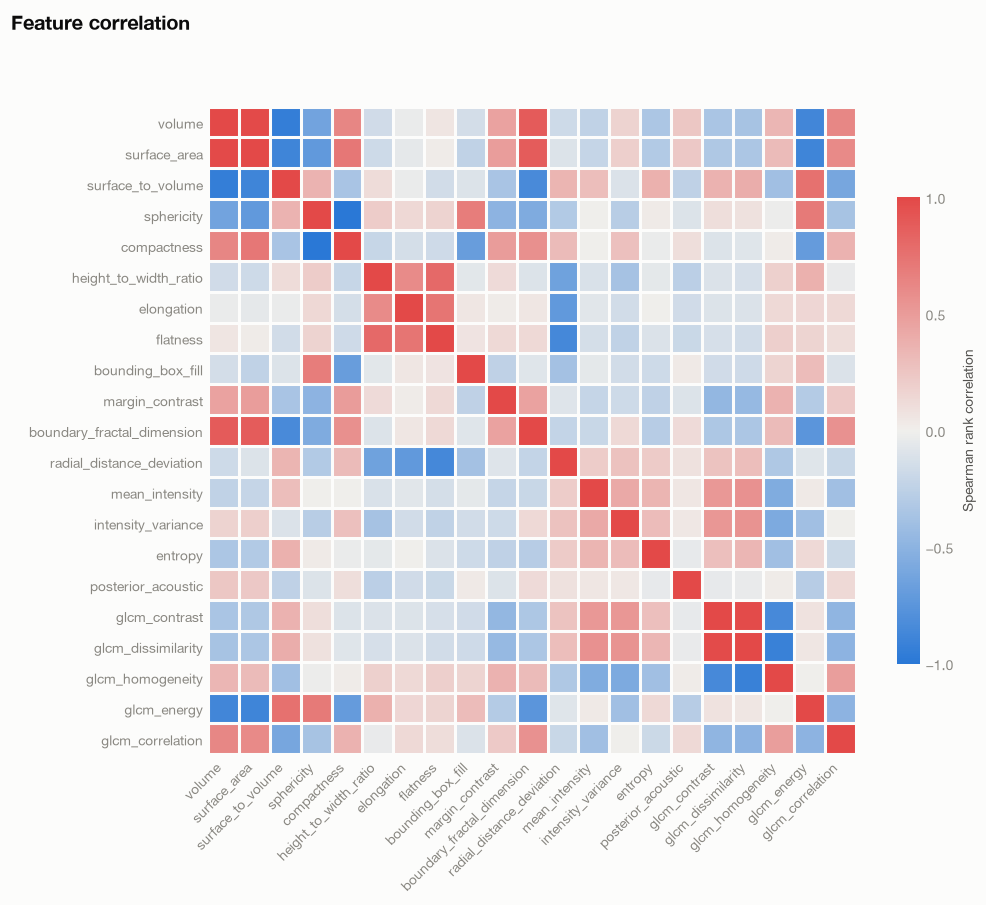

In [18]:
corr = features[FEATURE_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.4, 8.2))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)), FEATURE_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURE_COLS)), FEATURE_COLS)
ax.tick_params(length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_xticks(np.arange(len(FEATURE_COLS) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(FEATURE_COLS) + 1) - 0.5, minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)

cbar = fig.colorbar(im, ax=ax, shrink=0.72, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, colors=MUTED)
cbar.set_label("Spearman rank correlation", color=INK_2, fontsize=9)

top = fig_title(fig, "Feature correlation")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

### The strongest feature with an independent partner

The top-ranked features largely restate one another (see the correlation block), so plotting the top
two would show one quantity twice. This pairs the strongest feature with the most separable one that is
not strongly correlated with it (|ρ| < 0.5) — the raw material a classifier needs, and a visual check
on how much overlap it has to resolve.

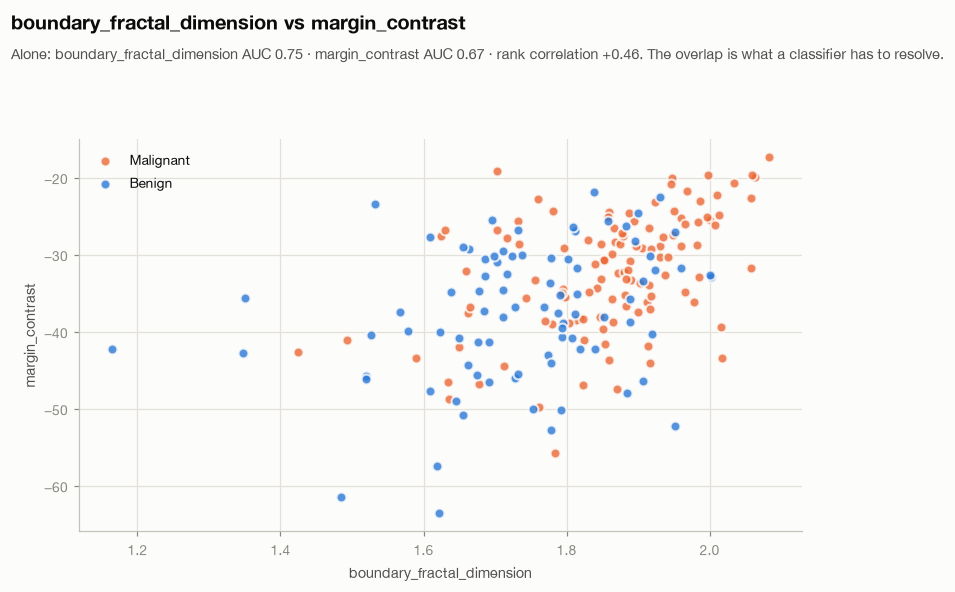

In [19]:
fx = summary.iloc[0]["feature"]
rank_corr = corr[fx].abs()
fy = next(f for f in summary["feature"].iloc[1:] if rank_corr[f] < 0.5)
auc_of = summary.set_index("feature")["auc"]

fig, ax = plt.subplots(figsize=(7.4, 5.6))
for cls in (0, 1):
    sub = features[features["label"] == cls]
    ax.scatter(sub[fx], sub[fy], s=42, color=CLASS_COLOR[cls], alpha=0.8,
               edgecolor=SURFACE, linewidth=1.4, label=CLASS_NAME[cls], zorder=3)

if fx in LOG_SCALE:
    ax.set_xscale("log")
if fy in LOG_SCALE:
    ax.set_yscale("log")
ax.set_xlabel(fx)
ax.set_ylabel(fy)
value_grid(ax, axis="both")
ax.legend(loc="best")

top = fig_title(fig, f"{fx} vs {fy}",
                f"Alone: {fx} AUC {auc_of[fx]:.2f} · {fy} AUC {auc_of[fy]:.2f} · rank correlation "
                f"{corr.loc[fx, fy]:+.2f}. The overlap is what a classifier has to resolve.")
fig.tight_layout(rect=[0, 0, 1, top])
plt.show()

## Takeaways

- **The dataset is small and imbalanced.** 200 lesions, 57–58% malignant in every split. With this few
  cases a handful of samples moves accuracy by a full point, so report AUC alongside accuracy and
  prefer cross-validation to a single split.
- **Measure in millimetres, and resample before surface-based features.** TDSC-ABUS voxels measure
  0.200 x 0.073 x 0.476 mm. Counted in voxels the average lesion box is 128 x 169 x 32, which looks like a
  thin slab; in millimetres it is 25.5 x 12.3 x 15.4 mm, wider than tall like most breast lesions. The
  distortion reaches the features: on this spacing a perfect sphere has sphericity 0.63 measured in
  voxels, 0.82 with the physical spacing passed to marching cubes, and 0.92 after resampling to 0.6 mm
  cubes — which is what `extract_radiology_features` does.
- **Mesh-derived features need `pad=2, preprocess=False`.** Either mistake yields an open surface and a
  negative volume, which silently poisons every volume, area and sphericity feature built on it — and it
  fails on exactly the large malignant lesions that matter most.
- **Shape carries the signal; echo pattern barely does.** The best single features are boundary fractal
  dimension (AUC 0.75), surface area and compactness (0.74), sphericity (0.74, lower in malignant) and
  volume (0.73). Mean intensity, entropy and posterior acoustic contrast sit between 0.48 and 0.56.
- **Most of that shape signal is lesion size.** Surface area, fractal dimension, surface-to-volume ratio
  and GLCM energy all track log volume with |ρ| ≥ 0.87, and sphericity and compactness are the same
  quantity (ρ = −1.00). A model effectively sees one size factor and one irregularity factor, so pick
  representatives or decorrelate before fitting a linear model.
- **Few lesions are taller than wide.** Depth exceeds the extent along the transducer in 3% of malignant
  lesions and none of the benign ones, so the classic ultrasound sign separates weakly here (AUC 0.60).
  Tan's volumetric version in `tao2013.ipynb` is similarly weak (0.63).